In [2]:
from pathlib import Path
import selfmadefunctions
import importlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
importlib.reload(selfmadefunctions)

# Author: Manou Liesker. Student number: 15250946

Selfmadefuntions imported/reloaded
Selfmadefuntions imported/reloaded


<module 'selfmadefunctions' from 'c:\\Users\\DTA180363\\Documents\\GitHub\\paperstack\\Manou_version\\code\\selfmadefunctions.py'>

This notebook is used to process the experiments I'm doing during my thesis. 

The cell below is used to read and track the videos, and save the y-coordinates into a CSV file (the y coordinates are already normalized). 

Having problems? Look at the outputfolder to see what part of tracking went wrong. Tweak the function accordingly. tresholdvalue is a good one to start with.



In [17]:
importlib.reload(selfmadefunctions)

inputfolder = Path(rf"Z:\Video_files\Experiments\Raw_Videos\80density")
outputfolder = Path(rf"Z:\Video_files\Experiments\Tracked_Videos\80density")
csvfolder = Path(rf"Z:\\Clean_Data\Data_Manou_Thesis_Clean\80density")

thicknesses = [20, 30, 40, 60, 80, 100, 120] 

for t in thicknesses:
    for i in range(1, 4):
        filename = f"80d_{t}t_{i}.avi"
        print(filename)
        selfmadefunctions.track_video_2(80, video_inputfolder=inputfolder, 
                                video_outputfolder=outputfolder, 
                                csv_outputfolder=csvfolder, filename=filename, 
                                show=False, save_video=True, save_csv=True, BOTTOM_CROP = 0, TOP_CROP = 40)

Selfmadefuntions imported/reloaded
80d_20t_1.avi
Saved video to: Z:\Video_files\Experiments\Tracked_Videos\80density\80d_20t_1_tracked.avi
Saved as Z:\Clean_Data\Data_Manou_Thesis_Clean\80density\80d_20t_1_clean.csv
80d_20t_2.avi
Saved video to: Z:\Video_files\Experiments\Tracked_Videos\80density\80d_20t_2_tracked.avi
Saved as Z:\Clean_Data\Data_Manou_Thesis_Clean\80density\80d_20t_2_clean.csv
80d_20t_3.avi
Saved video to: Z:\Video_files\Experiments\Tracked_Videos\80density\80d_20t_3_tracked.avi
Saved as Z:\Clean_Data\Data_Manou_Thesis_Clean\80density\80d_20t_3_clean.csv
80d_30t_1.avi
Saved video to: Z:\Video_files\Experiments\Tracked_Videos\80density\80d_30t_1_tracked.avi
Saved as Z:\Clean_Data\Data_Manou_Thesis_Clean\80density\80d_30t_1_clean.csv
80d_30t_2.avi
Saved video to: Z:\Video_files\Experiments\Tracked_Videos\80density\80d_30t_2_tracked.avi
Saved as Z:\Clean_Data\Data_Manou_Thesis_Clean\80density\80d_30t_2_clean.csv
80d_30t_3.avi
Saved video to: Z:\Video_files\Experiments\Tra

The function COR_calculator_general is meant to be able to read a clean csv file, and be given the name of the variable you are changing (such as thickness etc.) to ouput graphs (if Find_Plot = true) to check if everything went right. The function returns the calculated COR.

In [37]:
importlib.reload(selfmadefunctions)
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\80density")

variable_type = "Number of Papers"
Thickness_80d_unique = [0, 1, 5, 10, 20, 30, 40, 60, 80, 100, 120]
Thickness_80d = []
COR_80d = []
Thickness_80d_mm = []

for t in Thickness_80d_unique:
    variable_value = f"{t} papers"
    
    for j in range(1, 4):
        filename = f"80d_{t}t_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_80d.append(cor_value)
        Thickness_80d.append(t)

Thickness_80d, COR_80d, COR_err_80d, avg_COR_80d, Thickness_80d_unique = selfmadefunctions.get_avg_err(Thickness_80d, COR_80d)

for t in Thickness_80d_unique:
    Thickness_80d_mm.append(t * 0.1)

Selfmadefuntions imported/reloaded


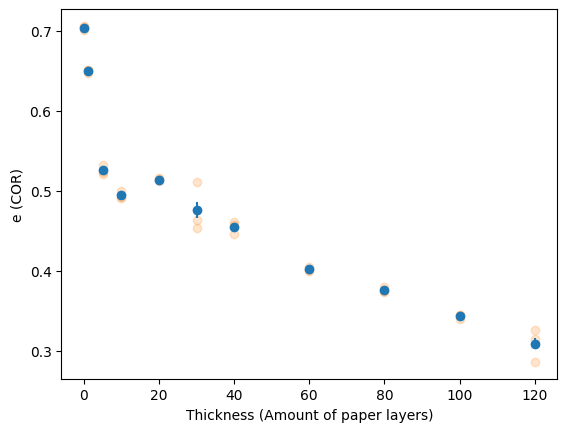

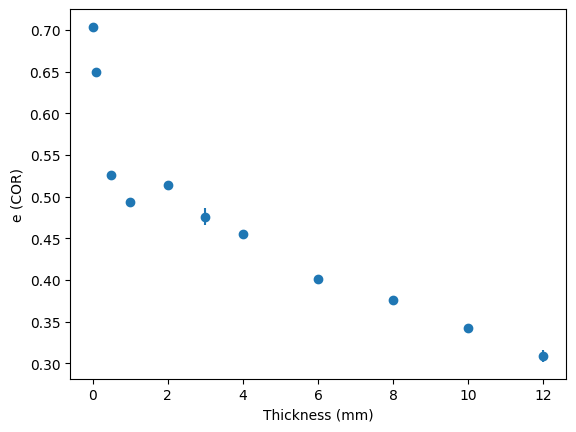

In [38]:
plt.errorbar(Thickness_80d_unique, avg_COR_80d, yerr = COR_err_80d, fmt = 'o', zorder = 2)
plt.errorbar(Thickness_80d, COR_80d, fmt = 'o', alpha = 0.2, zorder = 1)
plt.ylabel("e (COR)")
plt.xlabel("Thickness (Amount of paper layers)")
plt.show()

plt.errorbar(Thickness_80d_mm, avg_COR_80d, yerr = COR_err_80d, fmt = 'o', zorder = 2)
plt.ylabel("e (COR)")
plt.xlabel("Thickness (mm)")
plt.show()

In [39]:
importlib.reload(selfmadefunctions)
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge")

variable_type = "distance from edge"
edge_100t = [i for i in range(2, 16) for _ in range(1, 4)]
COR_100t = []

for i in range(2, 16):
    variable_value = f"{i} cm"
    
    for j in range(1, 4):
        filename = f"20h_100t_{i}cm_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_100t.append(cor_value)



COR_100t[7] = np.nan #Mask weird value

edge_100t, COR_100t, COR_err_100t, avg_COR_100t, edge_unique_100t = selfmadefunctions.get_avg_err(edge_100t, COR_100t)





Selfmadefuntions imported/reloaded


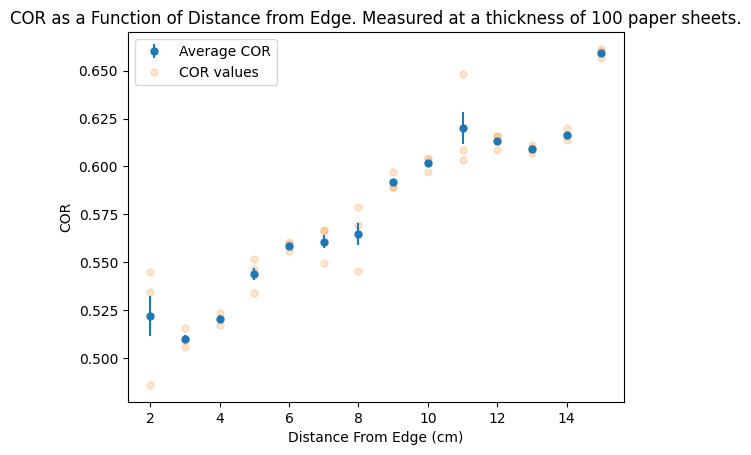

In [40]:
plt.errorbar(edge_unique_100t, avg_COR_100t, yerr=COR_err_100t, fmt = 'o', markersize=5, label='Average COR', zorder = 2)
plt.errorbar(edge_100t, COR_100t, fmt = 'o', markersize=5, label='COR values', zorder = 1, alpha = 0.2)
plt.xlabel('Distance From Edge (cm)')
plt.ylabel('COR')
plt.title('COR as a Function of Distance from Edge. Measured at a thickness of 100 paper sheets.')
plt.legend()
plt.show()

Selfmadefuntions imported/reloaded


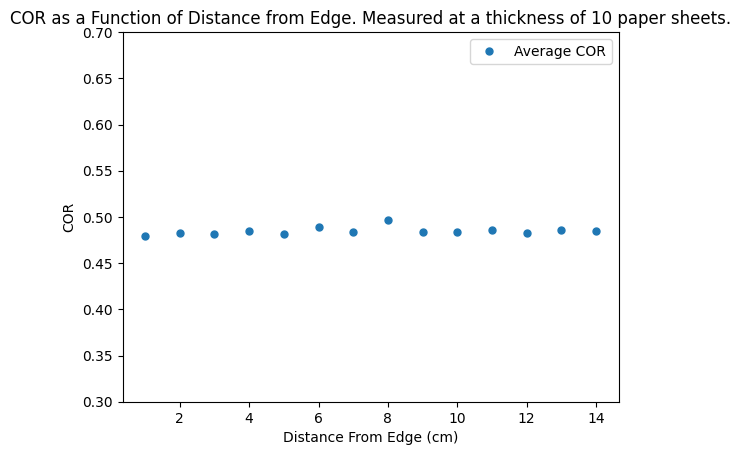

In [41]:
importlib.reload(selfmadefunctions)
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_10t")

variable_type = "distance from edge"
edge_10t = [i for i in range(1, 15)]
COR_10t = []

for i in range(1, 15):
    variable_value = f"{i} cm"
    
    for j in range(1, 2):
        filename = f"20h_10t_{i}cm_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_10t.append(cor_value)


plt.errorbar(edge_10t, COR_10t, fmt = 'o', markersize=5, label='Average COR', zorder = 2)
plt.ylim(0.3, 0.7)
plt.xlabel('Distance From Edge (cm)')
plt.ylabel('COR')
plt.title('COR as a Function of Distance from Edge. Measured at a thickness of 10 paper sheets.')
plt.legend()
plt.show()

In [42]:
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_300t")

variable_type = "distance from edge"
edge_300t = np.repeat(np.arange(2, 16), 3)
COR_300t = []

for i in range(2, 16):
    variable_value = f"{i} cm"
    
    for j in range(1, 4):
        filename = f"20h_300t_{i}cm_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_300t.append(cor_value)

COR_300t[16] = np.nan
COR_300t[20] = np.nan


Selfmadefuntions imported/reloaded


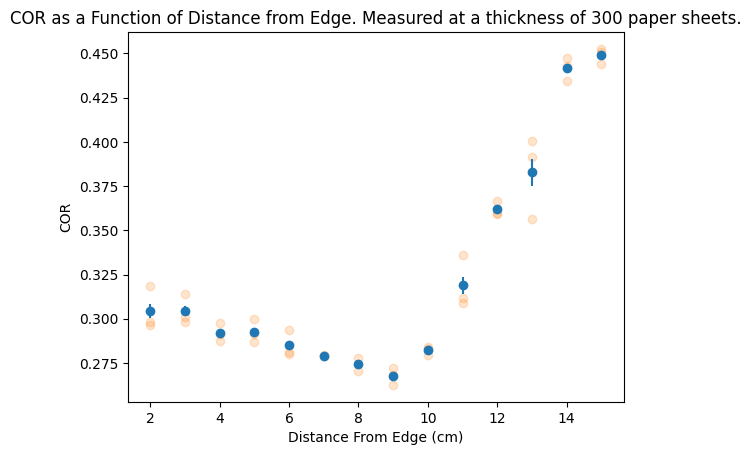

In [43]:
importlib.reload(selfmadefunctions)
edge_300t_clean, COR_300t_clean, COR_300t_err, avg_COR_300t, edge_unique_300t = selfmadefunctions.get_avg_err(edge_300t, COR_300t)

plt.errorbar(edge_unique_300t, avg_COR_300t, COR_300t_err, fmt = 'o', zorder = 2)
plt.errorbar(edge_300t_clean, COR_300t_clean, fmt = 'o', alpha = 0.2, zorder = 1)
plt.xlabel('Distance From Edge (cm)')
plt.ylabel('COR')
plt.title('COR as a Function of Distance from Edge. Measured at a thickness of 300 paper sheets.')
plt.show()

In [44]:
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_5t")

variable_type = "distance from edge"
unique_edge_5t = [2, 6, 9, 10, 11, 12, 13, 14]
edge_5t = np.repeat(unique_edge_5t, 3)
COR_5t = []



for i in unique_edge_5t:
    variable_value = f"{i} cm"
    
    for j in range(1, 4):
        filename = f"20h_5t_{i}cm_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_5t.append(cor_value)

print(COR_5t)

for i in range(len(COR_5t)):
    if COR_5t[i] > 1:
        COR_5t[i] = np.nan

[np.float64(0.5109938058983838), np.float64(0.5094775683833194), np.float64(0.5039829133417941), np.float64(0.4951020553979485), np.float64(0.5043454818155669), np.float64(0.48547178793143037), np.float64(0.500067683850971), np.float64(0.5033444991819184), np.float64(1.0196441817795545), np.float64(0.5014060405953348), np.float64(0.4938173142313406), np.float64(0.49794929575697194), np.float64(0.5050022124206169), np.float64(0.5068722762242563), np.float64(0.49862599322171397), np.float64(0.5082977352917811), np.float64(0.49454235590017687), np.float64(0.5090019298048473), np.float64(0.5095900881885473), np.float64(1.01930185035116), np.float64(0.49229215345831195), np.float64(0.507117601469079), np.float64(0.500682022768143), np.float64(0.5097870243128828)]


Selfmadefuntions imported/reloaded


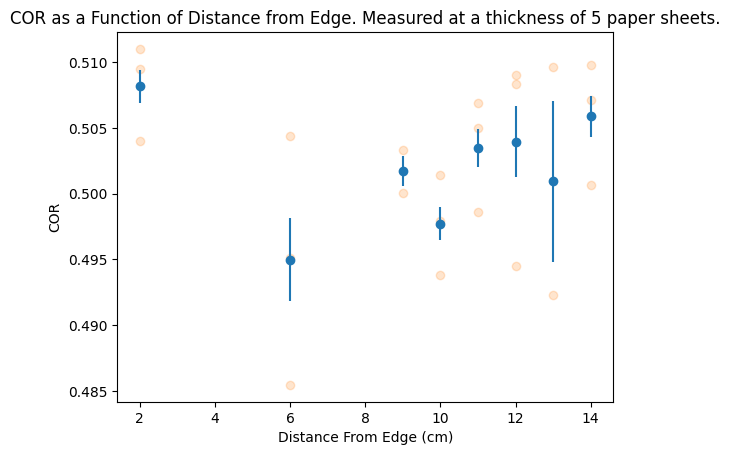

In [45]:
importlib.reload(selfmadefunctions)
edge_5t_clean, COR_5t_clean, COR_5t_err, avg_COR_5t, x_unique = selfmadefunctions.get_avg_err(edge_5t, COR_5t)


plt.errorbar(unique_edge_5t, avg_COR_5t, COR_5t_err, fmt = 'o', zorder = 2)
plt.errorbar(edge_5t_clean, COR_5t_clean, fmt = 'o', alpha = 0.2, zorder = 1)
plt.xlabel('Distance From Edge (cm)')
plt.ylabel('COR')
plt.title('COR as a Function of Distance from Edge. Measured at a thickness of 5 paper sheets.')
plt.show()

In [46]:
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_50t")
importlib.reload(selfmadefunctions)

variable_type = "distance from edge"
edge_50t = np.repeat(np.arange(2, 16), 3)
COR_50t = []

for i in range(2, 16):
    variable_value = f"{i} cm"
    
    for j in range(1, 4):
        filename = f"20h_50t_{i}cm_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_50t.append(cor_value)

edge_50t_clean, COR_50t_clean, COR_50t_err, avg_COR_50t, edge_50t_unique = selfmadefunctions.get_avg_err(edge_50t, COR_50t)

Selfmadefuntions imported/reloaded


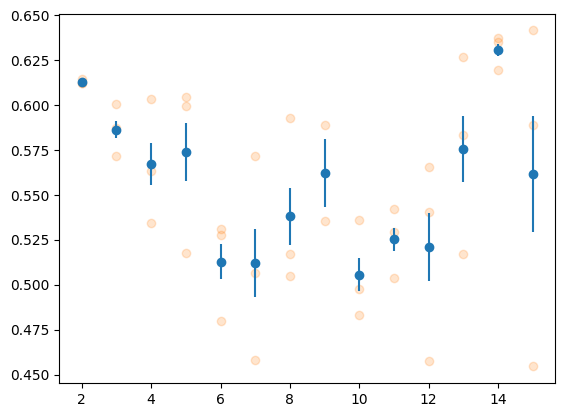

In [47]:
plt.errorbar(edge_50t_unique, avg_COR_50t,  COR_50t_err, fmt = 'o', zorder = 2)
plt.errorbar(edge_50t_clean, COR_50t_clean, fmt = 'o', zorder = 1, alpha = 0.2)
plt.show()

Selfmadefuntions imported/reloaded


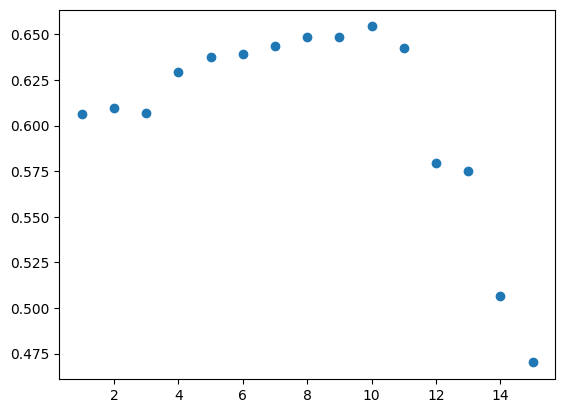

In [48]:
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\DFE_50t_Retry")
importlib.reload(selfmadefunctions)

variable_type = "distance from edge"
edge_50t_retry = np.arange(1, 16)
COR_50t_retry = []

for i in range(1, 16):
    variable_value = f"{i} cm"
    filename = f"50t_retry_{i}_clean"
    cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                variable_type=variable_type, 
                                                                variable_value=variable_value, 
                                                                filename=filename, Find_Plot=False,
                                                                Fit_Plot=False, Fit_Report=False)
    COR_50t_retry.append(cor_value)


plt.errorbar(edge_50t_retry, COR_50t_retry, fmt = 'o')
plt.show()

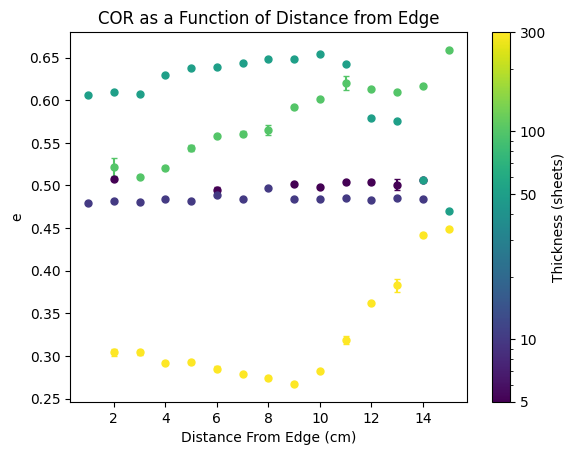

In [49]:
# thickness values
thicknesses = [5, 10, 50, 100, 300]

# normalize thickness range for the colormap
norm = mpl.colors.LogNorm(vmin=min(thicknesses), vmax=max(thicknesses))
cmap = plt.cm.viridis   # you can also try plasma, turbo, inferno

fig, ax = plt.subplots()

ax.errorbar(unique_edge_5t,   avg_COR_5t,   yerr=COR_5t_err,   fmt='o',
            color=cmap(norm(5)),   markersize=5, capsize=2, label='5 sheets')
ax.errorbar(edge_10t,         COR_10t,      fmt='o',
            color=cmap(norm(10)),  markersize=5, capsize=2, label='10 sheets')
ax.errorbar(edge_50t_retry, COR_50t_retry, fmt = 'o',
            color=cmap(norm(50)),   markersize=5, capsize=2, label='50 sheets')
ax.errorbar(edge_unique_100t, avg_COR_100t, yerr=COR_err_100t, fmt='o',
            color=cmap(norm(100)), markersize=5, capsize=2, label='100 sheets')
ax.errorbar(edge_unique_300t, avg_COR_300t, yerr=COR_300t_err, fmt='o',
            color=cmap(norm(300)), markersize=5, capsize=2, label='300 sheets')

ax.set_xlabel('Distance From Edge (cm)')
ax.set_ylabel('e')
ax.set_title('COR as a Function of Distance from Edge')

# colorbar instead of relying only on legend
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Thickness (sheets)')
cbar.set_ticks(thicknesses)
cbar.set_ticklabels(thicknesses)
plt.show()

In [50]:
importlib.reload(selfmadefunctions)
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\160density")

variable_type = "amount of paper sheets"
thickness_unique_160d = [1, 2, 3, 4, 5, 7, 10, 15, 20, 25, 30, 50, 100, 150, 200, 250, 300, 400, 500]
thickness_160d = []
COR_160d = []

for t in thickness_unique_160d:
    variable_value = f"{t} paper sheets"
    
    for i in range(1, 4):
        filename = f"160d_{t}t_{i}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR_160d.append(cor_value)
        thickness_160d.append(t)


Selfmadefuntions imported/reloaded


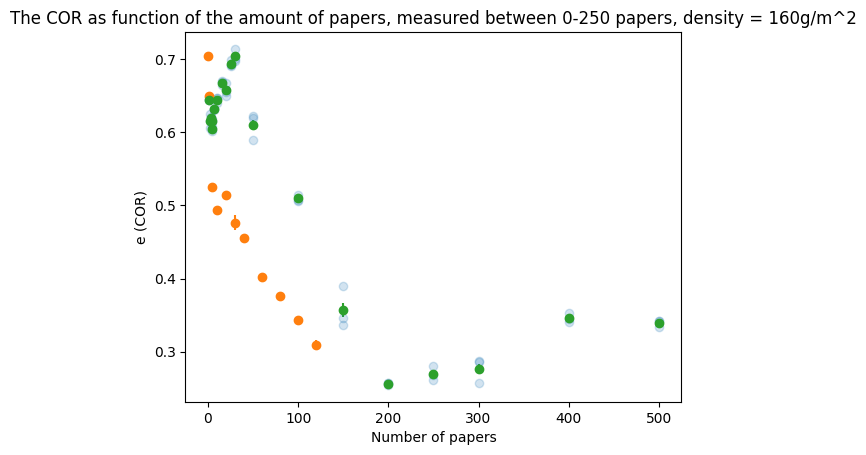

In [52]:
thickness_160d, COR_160d, COR_err_160d, avg_COR_160d, thickness_unique_160d = selfmadefunctions.get_avg_err(thickness_160d, COR_160d)
plt.errorbar(thickness_160d, COR_160d, fmt = 'o', alpha = 0.2, label = 'All Measurements')
plt.errorbar(Thickness_80d_unique, avg_COR_80d, yerr = COR_err_80d, fmt = 'o', zorder = 2)
plt.errorbar(thickness_unique_160d, avg_COR_160d, yerr = COR_err_160d, fmt = 'o', label = 'Average COR')
plt.ylabel("e (COR)")
plt.xlabel("Number of papers")
plt.title("The COR as function of the amount of papers, measured between 0-250 papers, density = 160g/m^2")
plt.show()